# Qwen / MLX Evaluation Notebook

This notebook documents the current Qwen2.5-VL + MLX evaluation workflow for the project **Trustworthy Assistive Visual Question Answering for Blind and Low-Vision Users**.

This notebook includes:
- processed dataset inspection
- training log summary
- MLX training loss visualization
- Qwen evaluation metrics
- prediction analysis
- qualitative examples with images

Note:
- The current most reliable Qwen result comes from the **base model only**
- The fine-tuned adapter is still under refinement

In [1]:
import os
import json
import re
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

In [6]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()

# If notebook is run from notebooks/, move one level up
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

TRAIN_JSONL = PROJECT_ROOT / "data" / "processed" / "mlx_train.jsonl"
VAL_JSONL = PROJECT_ROOT / "data" / "processed" / "mlx_val.jsonl"

TRAIN_LOG = PROJECT_ROOT / "results" / "mlx_qwen" / "logs" / "mlx_train_log.txt"
LOSS_PLOT = PROJECT_ROOT / "results" / "mlx_qwen" / "plots" / "mlx_train_loss.png"
PREDICTIONS_CSV = PROJECT_ROOT / "results" / "mlx_qwen" / "predictions" / "mlx_val_predictions.csv"
METRICS_JSON = PROJECT_ROOT / "results" / "mlx_qwen" / "metrics" / "mlx_eval_metrics.json"

print("Project root:", PROJECT_ROOT)
print("Train JSONL:", TRAIN_JSONL)
print("Val JSONL:", VAL_JSONL)

Project root: /Users/ajithreddy/Desktop/trustworthy-assistive-vqa
Train JSONL: /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/data/processed/mlx_train.jsonl
Val JSONL: /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/data/processed/mlx_val.jsonl


In [10]:
paths = {
    "TRAIN_JSONL": TRAIN_JSONL,
    "VAL_JSONL": VAL_JSONL,
    "TRAIN_LOG": TRAIN_LOG,
    "LOSS_PLOT": LOSS_PLOT,
    "PREDICTIONS_CSV": PREDICTIONS_CSV,
    "METRICS_JSON": METRICS_JSON,
}

for name, path in paths.items():
    print(f"{name}: {'FOUND' if path.exists() else 'MISSING'} -> {path}")

TRAIN_JSONL: FOUND -> /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/data/processed/mlx_train.jsonl
VAL_JSONL: FOUND -> /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/data/processed/mlx_val.jsonl
TRAIN_LOG: FOUND -> /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/results/mlx_qwen/logs/mlx_train_log.txt
LOSS_PLOT: FOUND -> /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/results/mlx_qwen/plots/mlx_train_loss.png
PREDICTIONS_CSV: FOUND -> /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/results/mlx_qwen/predictions/mlx_val_predictions.csv
METRICS_JSON: FOUND -> /Users/ajithreddy/Desktop/trustworthy-assistive-vqa/results/mlx_qwen/metrics/mlx_eval_metrics.json


In [11]:
import json
import pandas as pd

def load_jsonl(path, max_rows=None):
    rows = []
    with open(path, "r") as f:
        for i, line in enumerate(f):
            if max_rows is not None and i >= max_rows:
                break
            rows.append(json.loads(line))
    return pd.DataFrame(rows)

In [12]:
train_preview = load_jsonl(TRAIN_JSONL, max_rows=5)
val_preview = load_jsonl(VAL_JSONL, max_rows=5)

print("Train preview:")
display(train_preview)

print("\nValidation preview:")
display(val_preview)

Train preview:


,image,question,answer
0,data/raw/vizwiz/train/VizWiz_train_00000001.jpg,You are a trustworthy assistive visual questio...,coca cola
1,data/raw/vizwiz/train/VizWiz_train_00000002.jpg,You are a trustworthy assistive visual questio...,tomatoes
2,data/raw/vizwiz/train/VizWiz_train_00000005.jpg,You are a trustworthy assistive visual questio...,shoes
3,data/raw/vizwiz/train/VizWiz_train_00000008.jpg,You are a trustworthy assistive visual questio...,orange
4,data/raw/vizwiz/train/VizWiz_train_00000009.jpg,You are a trustworthy assistive visual questio...,yes



Validation preview:


,image,question,answer
0,data/raw/vizwiz/val/VizWiz_val_00000000.jpg,You are a trustworthy assistive visual questio...,unanswerable
1,data/raw/vizwiz/val/VizWiz_val_00000003.jpg,You are a trustworthy assistive visual questio...,right
2,data/raw/vizwiz/val/VizWiz_val_00000004.jpg,You are a trustworthy assistive visual questio...,unanswerable
3,data/raw/vizwiz/val/VizWiz_val_00000005.jpg,You are a trustworthy assistive visual questio...,unanswerable
4,data/raw/vizwiz/val/VizWiz_val_00000006.jpg,You are a trustworthy assistive visual questio...,unanswerable


In [13]:
train_df = load_jsonl(TRAIN_JSONL)
val_df = load_jsonl(VAL_JSONL)

summary_df = pd.DataFrame({
    "Split": ["Train", "Validation"],
    "Num Samples": [len(train_df), len(val_df)]
})

display(summary_df)

,Split,Num Samples
0,Train,1500
1,Validation,300


In [14]:
def unanswerable_fraction(df):
    return (df["answer"].astype(str).str.lower() == "unanswerable").mean()

unans_df = pd.DataFrame({
    "Split": ["Train", "Validation"],
    "Unanswerable Fraction": [
        unanswerable_fraction(train_df),
        unanswerable_fraction(val_df)
    ]
})

display(unans_df)

,Split,Unanswerable Fraction
0,Train,0.553333
1,Validation,0.800000


In [15]:
with open(TRAIN_LOG, "r") as f:
    log_lines = f.readlines()

iter_lines = [line.strip() for line in log_lines if line.startswith("Iter ") and "Train loss" in line]

print(f"Number of logged training points: {len(iter_lines)}")
print("\nFirst 5 lines:")
for line in iter_lines[:5]:
    print(line)

print("\nLast 5 lines:")
for line in iter_lines[-5:]:
    print(line)

Number of logged training points: 150

First 5 lines:
Iter 10: Train loss 5.32247772, Learning Rate 1.000e-05, It/sec 3.233, Tokens/sec 106.689, Trained Tokens 330, Peak mem 3.481 GB
Iter 20: Train loss 1.35989151, Learning Rate 1.000e-05, It/sec 3.897, Tokens/sec 128.592, Trained Tokens 660, Peak mem 3.481 GB
Iter 30: Train loss 1.82082539, Learning Rate 1.000e-05, It/sec 4.169, Tokens/sec 137.561, Trained Tokens 990, Peak mem 3.481 GB
Iter 40: Train loss 6.70699387, Learning Rate 1.000e-05, It/sec 4.097, Tokens/sec 135.207, Trained Tokens 1320, Peak mem 3.481 GB
Iter 50: Train loss 5.38222275, Learning Rate 1.000e-05, It/sec 4.015, Tokens/sec 132.490, Trained Tokens 1650, Peak mem 3.481 GB

Last 5 lines:
Iter 1460: Train loss 0.71017160, Learning Rate 1.000e-05, It/sec 3.973, Tokens/sec 131.108, Trained Tokens 48180, Peak mem 3.481 GB
Iter 1470: Train loss 0.71001687, Learning Rate 1.000e-05, It/sec 3.811, Tokens/sec 125.770, Trained Tokens 48510, Peak mem 3.481 GB
Iter 1480: Train l

In [16]:
pattern = re.compile(r"Iter\s+(\d+):\s+Train loss\s+([0-9.]+)")

iters = []
losses = []

for line in iter_lines:
    match = pattern.search(line)
    if match:
        iters.append(int(match.group(1)))
        losses.append(float(match.group(2)))

log_df = pd.DataFrame({
    "Iteration": iters,
    "Train Loss": losses
})

display(log_df.head())
display(log_df.tail())

,Iteration,Train Loss
0,10,5.322478
1,20,1.359892
2,30,1.820825
3,40,6.706994
4,50,5.382223


,Iteration,Train Loss
145,1460,0.710172
146,1470,0.710017
147,1480,0.710204
148,1490,0.710115
149,1500,0.710289


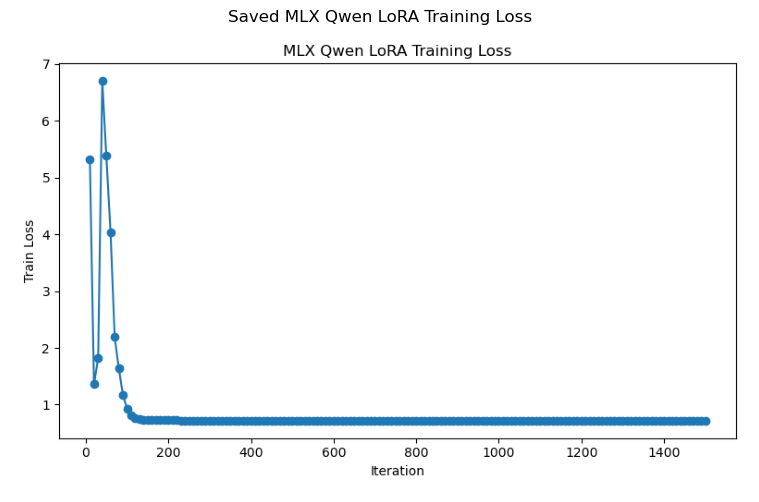

In [17]:
img = Image.open(LOSS_PLOT)
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Saved MLX Qwen LoRA Training Loss")
plt.show()

In [19]:
with open(METRICS_JSON, "r") as f:
    metrics = json.load(f)

metrics_df = pd.DataFrame(list(metrics.items()), columns=["Metric", "Value"])
display(metrics_df)

,Metric,Value
0,num_samples,100
1,exact_match_accuracy,0.76
2,unanswerable_recall,0.879518
3,adapter_used,base_model_only


In [20]:
display(Markdown(f"""
## Preliminary Qwen Evaluation Summary

- Number of evaluated samples: **{metrics.get('num_samples', 'N/A')}**
- Exact-match accuracy: **{metrics.get('exact_match_accuracy', 'N/A')}**
- Unanswerable recall: **{metrics.get('unanswerable_recall', 'N/A')}**
- Model setting: **{metrics.get('adapter_used', 'N/A')}**

Current interpretation:
- The base Qwen model is producing mostly sensible outputs on the small validation sample.
- The model performs strongly on many **unanswerable** cases.
- It still shows a strong abstention bias and misses some answerable cases.
- The fine-tuned adapter is still under refinement, so the current strongest Qwen result is from the base model.
"""))


## Preliminary Qwen Evaluation Summary

- Number of evaluated samples: **100**
- Exact-match accuracy: **0.76**
- Unanswerable recall: **0.8795180722891566**
- Model setting: **base_model_only**

Current interpretation:
- The base Qwen model is producing mostly sensible outputs on the small validation sample.
- The model performs strongly on many **unanswerable** cases.
- It still shows a strong abstention bias and misses some answerable cases.
- The fine-tuned adapter is still under refinement, so the current strongest Qwen result is from the base model.


In [21]:
pred_df = pd.read_csv(PREDICTIONS_CSV)
display(pred_df.head(10))

,image,question,ground_truth,prediction,ground_truth_normalized,prediction_normalized,exact_match
0,data/raw/vizwiz/val/VizWiz_val_00000000.jpg,ok. there is another picture i hope it is a be...,unanswerable,unanswerable.,unanswerable,unanswerable,1
1,data/raw/vizwiz/val/VizWiz_val_00000003.jpg,which one is the blue one?,right,unanswerable.,right,unanswerable,0
2,data/raw/vizwiz/val/VizWiz_val_00000004.jpg,what does the arrow say?,unanswerable,unanswerable.,unanswerable,unanswerable,1
3,data/raw/vizwiz/val/VizWiz_val_00000005.jpg,what the screen says? thank you.,unanswerable,unanswerable,unanswerable,unanswerable,1
4,data/raw/vizwiz/val/VizWiz_val_00000006.jpg,what is seen on the laptop screen? what is see...,unanswerable,unanswerable,unanswerable,unanswerable,1
5,data/raw/vizwiz/val/VizWiz_val_00000007.jpg,okay i think i got it this time. can you read ...,unanswerable,unanswerable.,unanswerable,unanswerable,1
6,data/raw/vizwiz/val/VizWiz_val_00000008.jpg,is this shampoo or conditioner?,unanswerable,unanswerable,unanswerable,unanswerable,1
7,data/raw/vizwiz/val/VizWiz_val_00000009.jpg,can you describe for me what's going on outsid...,nothing,!!!!!!!!!!!!!!!!!!!!!!!!,nothing,NaN,0
8,data/raw/vizwiz/val/VizWiz_val_00000010.jpg,what about the signery.,unanswerable,unanswerable.,unanswerable,unanswerable,1
9,data/raw/vizwiz/val/VizWiz_val_00000011.jpg,what color is this,white,white,white,white,1


In [22]:
pred_summary = pd.DataFrame({
    "Total Rows": [len(pred_df)],
    "Exact Matches": [pred_df["exact_match"].sum()],
    "Exact Match Rate": [pred_df["exact_match"].mean()]
})

display(pred_summary)

,Total Rows,Exact Matches,Exact Match Rate
0,100,76,0.76


In [23]:
pred_counts = pred_df["prediction_normalized"].fillna("").value_counts().head(10)
display(pred_counts.to_frame(name="Count"))

,Count
prediction_normalized,
unanswerable,83
,11
yes,2
white,1
pp41l,1
blue,1
that s all the information we need right now your computer will restart,1


In [24]:
mistakes_df = pred_df[pred_df["exact_match"] == 0].copy()
display(mistakes_df.head(15))

,image,question,ground_truth,prediction,ground_truth_normalized,prediction_normalized,exact_match
1,data/raw/vizwiz/val/VizWiz_val_00000003.jpg,which one is the blue one?,right,unanswerable.,right,unanswerable,0
7,data/raw/vizwiz/val/VizWiz_val_00000009.jpg,can you describe for me what's going on outsid...,nothing,!!!!!!!!!!!!!!!!!!!!!!!!,nothing,NaN,0
13,data/raw/vizwiz/val/VizWiz_val_00000015.jpg,which one of these items is the children's dic...,left,!!!!!!!!!!!!!!!!!!!!!!!!,left,NaN,0
17,data/raw/vizwiz/val/VizWiz_val_00000019.jpg,what is the tag number?,unanswerable,PP41L,unanswerable,pp41l,0
22,data/raw/vizwiz/val/VizWiz_val_00000028.jpg,is this a woman?>,yes,unanswerable,yes,unanswerable,0
30,data/raw/vizwiz/val/VizWiz_val_00000037.jpg,"hi, i just wanted to confirm that these are in...",yes,unanswerable.,yes,unanswerable,0
44,data/raw/vizwiz/val/VizWiz_val_00000053.jpg,"hello there, are you able to see what's on thi...",yes,unanswerable.,yes,unanswerable,0
49,data/raw/vizwiz/val/VizWiz_val_00000061.jpg,what is this?,computer screen,unanswerable,computer screen,unanswerable,0
54,data/raw/vizwiz/val/VizWiz_val_00000067.jpg,what's the website?,unanswerable,!!!!!!!!!!!!!!!!!!!!!!!!,unanswerable,NaN,0
58,data/raw/vizwiz/val/VizWiz_val_00000072.jpg,what does the sky look like in this photograph,clear,blue,clear,blue,0


In [25]:
correct_df = pred_df[pred_df["exact_match"] == 1].copy()
display(correct_df.head(15))

,image,question,ground_truth,prediction,ground_truth_normalized,prediction_normalized,exact_match
0,data/raw/vizwiz/val/VizWiz_val_00000000.jpg,ok. there is another picture i hope it is a be...,unanswerable,unanswerable.,unanswerable,unanswerable,1
2,data/raw/vizwiz/val/VizWiz_val_00000004.jpg,what does the arrow say?,unanswerable,unanswerable.,unanswerable,unanswerable,1
3,data/raw/vizwiz/val/VizWiz_val_00000005.jpg,what the screen says? thank you.,unanswerable,unanswerable,unanswerable,unanswerable,1
4,data/raw/vizwiz/val/VizWiz_val_00000006.jpg,what is seen on the laptop screen? what is see...,unanswerable,unanswerable,unanswerable,unanswerable,1
5,data/raw/vizwiz/val/VizWiz_val_00000007.jpg,okay i think i got it this time. can you read ...,unanswerable,unanswerable.,unanswerable,unanswerable,1
6,data/raw/vizwiz/val/VizWiz_val_00000008.jpg,is this shampoo or conditioner?,unanswerable,unanswerable,unanswerable,unanswerable,1
8,data/raw/vizwiz/val/VizWiz_val_00000010.jpg,what about the signery.,unanswerable,unanswerable.,unanswerable,unanswerable,1
9,data/raw/vizwiz/val/VizWiz_val_00000011.jpg,what color is this,white,white,white,white,1
10,data/raw/vizwiz/val/VizWiz_val_00000012.jpg,this piece of mail for and where is it from?,unanswerable,unanswerable,unanswerable,unanswerable,1
11,data/raw/vizwiz/val/VizWiz_val_00000013.jpg,who is this mail for?,unanswerable,unanswerable.,unanswerable,unanswerable,1


In [26]:
num_examples = min(5, len(pred_df))

for i in range(num_examples):
    row = pred_df.iloc[i]
    image_path = row["image"]

    print("=" * 100)
    print(f"Example {i+1}")
    print(f"Question                  : {row['question']}")
    print(f"Ground Truth              : {row['ground_truth']}")
    print(f"Prediction                : {row['prediction']}")
    print(f"Ground Truth Normalized   : {row['ground_truth_normalized']}")
    print(f"Prediction Normalized     : {row['prediction_normalized']}")
    print(f"Exact Match               : {row['exact_match']}")

    if os.path.exists(image_path):
        img = Image.open(image_path)
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Example {i+1}")
        plt.show()
    else:
        print(f"Image not found: {image_path}")

Example 1
Question                  : ok. there is another picture i hope it is a better one.
Ground Truth              : unanswerable
Prediction                : unanswerable.
Ground Truth Normalized   : unanswerable
Prediction Normalized     : unanswerable
Exact Match               : 1
Image not found: data/raw/vizwiz/val/VizWiz_val_00000000.jpg
Example 2
Question                  : which one is the blue one?
Ground Truth              : right
Prediction                : unanswerable.
Ground Truth Normalized   : right
Prediction Normalized     : unanswerable
Exact Match               : 0
Image not found: data/raw/vizwiz/val/VizWiz_val_00000003.jpg
Example 3
Question                  : what does the arrow say?
Ground Truth              : unanswerable
Prediction                : unanswerable.
Ground Truth Normalized   : unanswerable
Prediction Normalized     : unanswerable
Exact Match               : 1
Image not found: data/raw/vizwiz/val/VizWiz_val_00000004.jpg
Example 4
Question      

In [27]:
failed_examples = pred_df[pred_df["exact_match"] == 0].head(5)

for idx, row in failed_examples.iterrows():
    image_path = row["image"]

    print("=" * 100)
    print("Failure Case")
    print(f"Question                : {row['question']}")
    print(f"Ground Truth            : {row['ground_truth']}")
    print(f"Prediction              : {row['prediction']}")
    print(f"Ground Truth Normalized : {row['ground_truth_normalized']}")
    print(f"Prediction Normalized   : {row['prediction_normalized']}")

    if os.path.exists(image_path):
        img = Image.open(image_path)
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title("Failure Example")
        plt.show()

Failure Case
Question                : which one is the blue one?
Ground Truth            : right
Prediction              : unanswerable.
Ground Truth Normalized : right
Prediction Normalized   : unanswerable
Failure Case
Question                : can you describe for me what's going on outside the window? just curious.
Ground Truth            : nothing
Prediction              : !!!!!!!!!!!!!!!!!!!!!!!!
Ground Truth Normalized : nothing
Prediction Normalized   : nan
Failure Case
Question                : which one of these items is the children's dictionary? is it the one on the right, or the one on the left?
Ground Truth            : left
Prediction              : !!!!!!!!!!!!!!!!!!!!!!!!
Ground Truth Normalized : left
Prediction Normalized   : nan
Failure Case
Question                : what is the tag number?
Ground Truth            : unanswerable
Prediction              : PP41L
Ground Truth Normalized : unanswerable
Prediction Normalized   : pp41l
Failure Case
Question              

In [28]:
display(Markdown("""
## Discussion

The current Qwen/MLX evaluation shows that the generative vision-language pipeline is functional and can produce meaningful outputs on validation samples.

### Main strengths
- The model handles many unclear or low-information images by responding with **unanswerable**.
- The pipeline is working end-to-end with saved metrics, predictions, and plots.
- The base Qwen model provides a stronger open-vocabulary foundation than the earlier closed-vocabulary classifier.

### Main limitations
- The evaluation sample is still small.
- The predictions are dominated by **unanswerable** cases, so the current score must be interpreted carefully.
- The model still abstains on some answerable questions.
- The fine-tuned adapter is not yet the strongest usable version of the Qwen path.

### Practical conclusion
For now, the base Qwen result is the most reliable current evidence for the generative model direction, while adapter-based fine-tuning remains ongoing work.
"""))


## Discussion

The current Qwen/MLX evaluation shows that the generative vision-language pipeline is functional and can produce meaningful outputs on validation samples.

### Main strengths
- The model handles many unclear or low-information images by responding with **unanswerable**.
- The pipeline is working end-to-end with saved metrics, predictions, and plots.
- The base Qwen model provides a stronger open-vocabulary foundation than the earlier closed-vocabulary classifier.

### Main limitations
- The evaluation sample is still small.
- The predictions are dominated by **unanswerable** cases, so the current score must be interpreted carefully.
- The model still abstains on some answerable questions.
- The fine-tuned adapter is not yet the strongest usable version of the Qwen path.

### Practical conclusion
For now, the base Qwen result is the most reliable current evidence for the generative model direction, while adapter-based fine-tuning remains ongoing work.


In [29]:
summary_export = pd.DataFrame({
    "Metric": [
        "Training samples",
        "Validation samples",
        "Qwen evaluation samples",
        "Exact-match accuracy",
        "Unanswerable recall",
        "Model setting"
    ],
    "Value": [
        len(train_df),
        len(val_df),
        metrics.get("num_samples", "N/A"),
        metrics.get("exact_match_accuracy", "N/A"),
        metrics.get("unanswerable_recall", "N/A"),
        metrics.get("adapter_used", "N/A")
    ]
})

display(summary_export)

,Metric,Value
0,Training samples,1500
1,Validation samples,300
2,Qwen evaluation samples,100
3,Exact-match accuracy,0.76
4,Unanswerable recall,0.879518
5,Model setting,base_model_only


In [30]:
display(Markdown("""
## Final Note

This notebook should be used as the main supporting notebook for the current Qwen/MLX direction in the repository.

Recommended repository notebook structure:

- `notebooks/setup.ipynb` -> dataset exploration and setup
- `notebooks/qwen_finetune_eval.ipynb` -> current Qwen/MLX evaluation evidence
"""))


## Final Note

This notebook should be used as the main supporting notebook for the current Qwen/MLX direction in the repository.

Recommended repository notebook structure:

- `notebooks/setup.ipynb` -> dataset exploration and setup
- `notebooks/qwen_finetune_eval.ipynb` -> current Qwen/MLX evaluation evidence
